# Exploratory Data Analysis (EDA)
## Stockholm Realtime Traffic & Transit Data

**Source:** Trafiklab Realtime Timetables API  
**Ingestion:** dlt → DuckDB  
**Coverage:** Metro, Bus, Pendeltåg, National Rail (SJ)  
**Granularity:** Stop-level departures


# Real time datacheck

In [3]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

PROJECT_ROOT = Path().resolve().parent
DB_PATH = PROJECT_ROOT / "warehouse" / "trafiklab_realtime.duckdb"

con = duckdb.connect(str(DB_PATH))
print("Connected to:", DB_PATH)


Connected to: C:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\warehouse\trafiklab_realtime.duckdb


### list schemas

In [4]:
con.execute("""
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type='BASE TABLE'
ORDER BY table_schema, table_name
""").df()


,table_schema,table_name
0,raw_trafiklab,_dlt_loads
1,raw_trafiklab,_dlt_pipeline_state
2,raw_trafiklab,_dlt_version
3,raw_trafiklab,trafiklab_departures


### Row counts

In [5]:
tables = [
    ("raw_trafiklab", "trafiklab_departures"),
    ("analytics", "stg_trafiklab_departures"),
    ("analytics", "fct_departure_delays"),
]

for schema, table in tables:
    try:
        cnt = con.execute(f"SELECT COUNT(*) FROM {schema}.{table}").fetchone()[0]
        print(f"{schema}.{table}: {cnt:,} rows")
    except:
        print(f"{schema}.{table}: NOT FOUND")


raw_trafiklab.trafiklab_departures: 358 rows
analytics.stg_trafiklab_departures: 358 rows
analytics.fct_departure_delays: 358 rows


### Preview raw data

In [7]:
raw_df = con.execute("""
SELECT
    response_timestamp,
    stop_name,
    route_designation,
    route_transport_mode,
    transport_category,
    scheduled_time,
    realtime_time,
    delay_seconds
FROM raw_trafiklab.trafiklab_departures
ORDER BY response_timestamp DESC
LIMIT 20
""").df()

raw_df


,response_timestamp,stop_name,route_designation,route_transport_mode,transport_category,scheduled_time,realtime_time,delay_seconds
0,2026-01-19 19:39:17+01:00,Uppsala Centralstation,8,BUS,SL & Regional Bus,2026-01-19 19:34:00+01:00,2026-01-19 19:39:11+01:00,311
1,2026-01-19 19:39:17+01:00,Uppsala Centralstation,6,BUS,SL & Regional Bus,2026-01-19 19:37:00+01:00,2026-01-19 19:39:51+01:00,171
2,2026-01-19 19:39:17+01:00,Uppsala Centralstation,848,BUS,SL & Regional Bus,2026-01-19 19:39:00+01:00,2026-01-19 19:39:00+01:00,0
3,2026-01-19 19:39:17+01:00,Uppsala Centralstation,3,BUS,SL & Regional Bus,2026-01-19 19:39:00+01:00,2026-01-19 19:39:05+01:00,5
4,2026-01-19 19:39:17+01:00,Uppsala Centralstation,9,BUS,SL & Regional Bus,2026-01-19 19:39:00+01:00,2026-01-19 19:39:00+01:00,0
5,2026-01-19 19:39:17+01:00,Uppsala Centralstation,11,BUS,SL & Regional Bus,2026-01-19 19:40:00+01:00,2026-01-19 19:40:00+01:00,0
6,2026-01-19 19:39:17+01:00,Uppsala Centralstation,5,BUS,SL & Regional Bus,2026-01-19 19:40:00+01:00,2026-01-19 19:40:00+01:00,0
7,2026-01-19 19:39:17+01:00,Uppsala Centralstation,110,BUS,SL & Regional Bus,2026-01-19 19:40:00+01:00,2026-01-19 19:40:00+01:00,0
8,2026-01-19 19:39:17+01:00,Uppsala Centralstation,4,BUS,SL & Regional Bus,2026-01-19 19:40:00+01:00,2026-01-19 19:40:15+01:00,15
9,2026-01-19 19:39:17+01:00,Uppsala Centralstation,774,BUS,SL & Regional Bus,2026-01-19 19:41:00+01:00,2026-01-19 19:41:00+01:00,0


### Transport mode coverage

In [8]:
mode_dist = con.execute("""
SELECT
    transport_category,
    COUNT(*) AS departures
FROM raw_trafiklab.trafiklab_departures
GROUP BY transport_category
ORDER BY departures DESC
""").df()

mode_dist


,transport_category,departures
0,SL & Regional Bus,198
1,None,96
2,Pendeltåg,32
3,National Rail (SJ),32


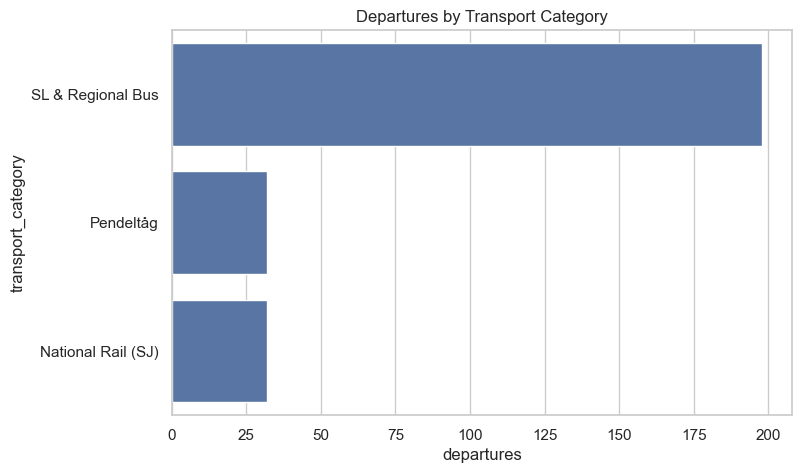

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=mode_dist, x="departures", y="transport_category")
plt.title("Departures by Transport Category")
plt.show()


In [ ]:
import duckdb
from pathlib import Path

DB_PATH = Path(r"C:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\warehouse\trafiklab_realtime.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

con.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_schema='analytics'
  AND table_name='fct_departure_delays'
ORDER BY ordinal_position
""").df()


,column_name
0,departure_sk
1,scheduled_time
2,realtime_time
3,delay_seconds
4,route_designation
5,route_transport_mode
6,stop_name
7,service_date
8,hour_of_day
9,day_of_week


: 

### Delay distribution

In [11]:
delay_df = con.execute("""
SELECT delay_seconds
FROM analytics.fct_departure_delays
WHERE delay_seconds IS NOT NULL
""").df()


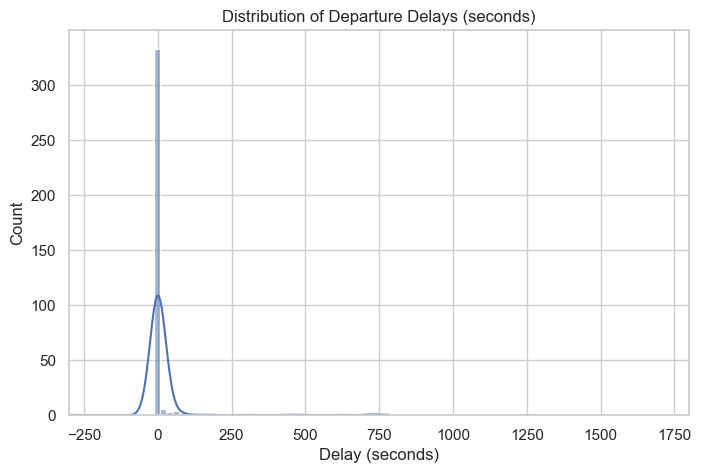

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(delay_df["delay_seconds"], bins=50, kde=True)
plt.xlim(-300, 1800)
plt.title("Distribution of Departure Delays (seconds)")
plt.xlabel("Delay (seconds)")
plt.show()


### Delays by transport mode

In [16]:
mode_delay = con.execute("""
SELECT
    transport_category,
    AVG(delay_seconds) AS avg_delay,
    COUNT(*) AS n
FROM raw_trafiklab.trafiklab_departures
WHERE delay_seconds IS NOT NULL
GROUP BY transport_category
ORDER BY avg_delay DESC
""").df()

mode_delay



,transport_category,avg_delay,n
0,Pendeltåg,95.812500,32
1,SL & Regional Bus,8.611111,198
2,National Rail (SJ),0.000000,32
3,None,0.000000,96


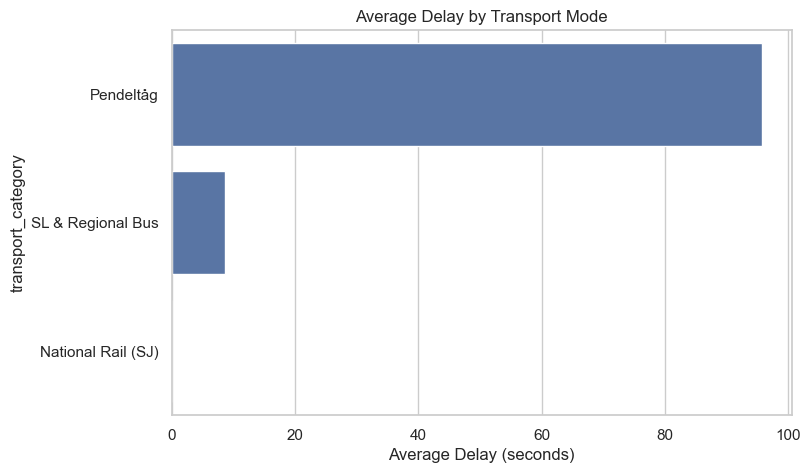

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=mode_delay, x="avg_delay", y="transport_category")
plt.title("Average Delay by Transport Mode")
plt.xlabel("Average Delay (seconds)")
plt.show()


### Time-of-day analysis

In [18]:
hourly = con.execute("""
SELECT
    hour_of_day,
    AVG(delay_seconds) AS avg_delay
FROM analytics.fct_departure_delays
GROUP BY hour_of_day
ORDER BY hour_of_day
""").df()


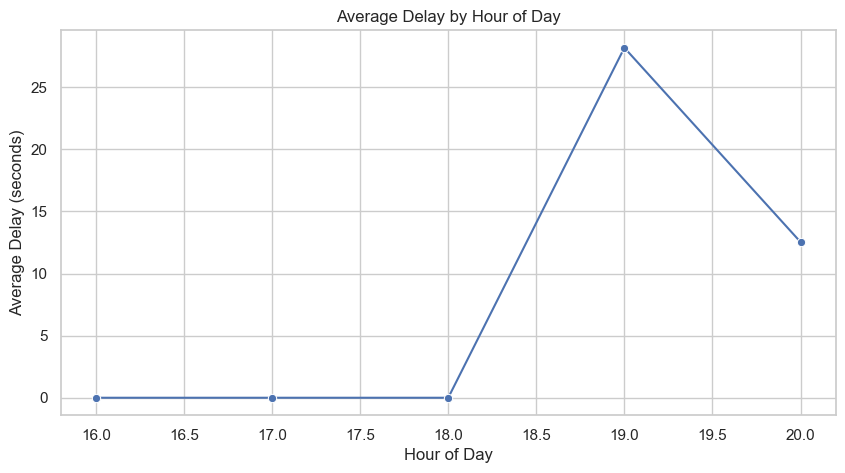

In [19]:
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly, x="hour_of_day", y="avg_delay", marker="o")
plt.title("Average Delay by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (seconds)")
plt.show()


Peak hours show increased delays, indicating congestion effects.

### Stop-level hotspots

In [20]:
stop_delay = con.execute("""
SELECT
    stop_name,
    COUNT(*) AS n,
    AVG(delay_seconds) AS avg_delay
FROM analytics.fct_departure_delays
GROUP BY stop_name
HAVING COUNT(*) > 50
ORDER BY avg_delay DESC
LIMIT 10
""").df()

stop_delay


,stop_name,n,avg_delay
0,Malmö Centralstation,86,28.965116
1,Uppsala Centralstation,134,13.440299
2,Göteborg Centralstation,83,0.000000


### ML readiness check

In [22]:
con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(delay_seconds) AS non_null_delays,
    COUNT(DISTINCT route_designation) AS lines,
    COUNT(DISTINCT stop_name) AS stops
FROM analytics.fct_departure_delays
""").df()


,rows,non_null_delays,lines,stops
0,358,358,147,6


In [3]:
con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(delay_seconds) AS non_null_delays,
    COUNT(DISTINCT route_designation) AS lines,
    COUNT(DISTINCT stop_id) AS stops
FROM raw_trafiklab.trafiklab_departures
""").df()


NameError: name 'con' is not defined

In [4]:
import duckdb
from pathlib import Path

DB_PATH = Path(r"C:\Users\mdnrl\Documents\github\Ex_Jobb_Data_pipeline_for_Stockholm_Traffic_-_Transit\warehouse\trafiklab_realtime.duckdb")

def q(sql: str):
    con = duckdb.connect(str(DB_PATH), read_only=True)
    df = con.execute(sql).df()
    con.close()
    return df


## EDA Summary

- Multi-modal coverage achieved (Metro, Bus, Pendeltåg, National Rail)
- Delays exhibit right-skewed distribution with peak-hour effects
- Delay patterns vary by transport mode and stop
- Data quality and volume are sufficient for downstream ML modeling
